In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

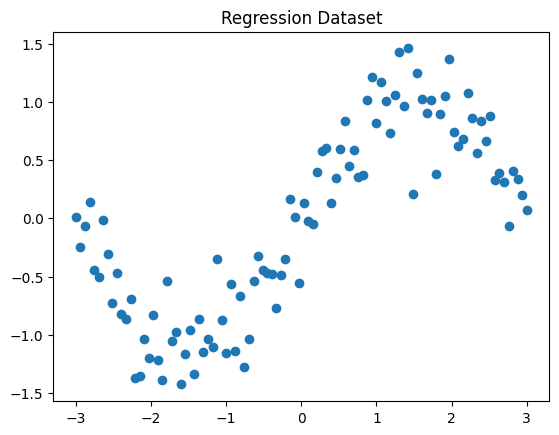

In [40]:
def generate_regression_data(n=100):
    X = np.linspace(-3, 3, n)
    y = np.sin(X) + 0.3 * np.random.randn(n)
    return X.reshape(-1, 1), y

X_reg, y_reg = generate_regression_data()

plt.scatter(X_reg, y_reg)
plt.title("Regression Dataset")
plt.show()

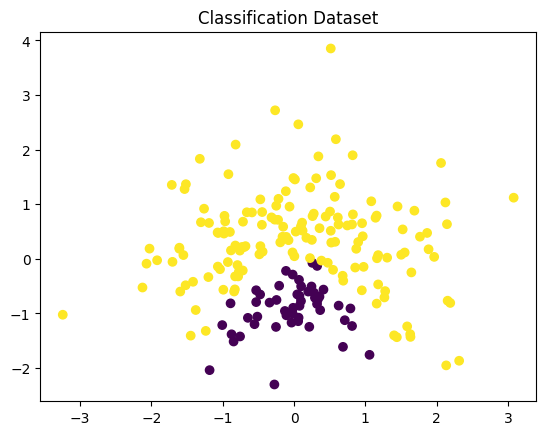

In [41]:
def generate_classification_data(n=200):
    X = np.random.randn(n, 2)
    y = (X[:, 0]**2 + X[:, 1] > 0).astype(int)
    return X, y

X_clf, y_clf = generate_classification_data()

plt.scatter(X_clf[:,0], X_clf[:,1], c=y_clf)
plt.title("Classification Dataset")
plt.show()

In [42]:
class LinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0

        self.losses = []

        for _ in range(self.epochs):
            y_pred = X @ self.w + self.b
            error = y_pred - y

            loss = np.mean(error**2)
            self.losses.append(loss)

            dw = (2/n) * X.T @ error
            db = (2/n) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return X @ self.w + self.b

In [43]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0

        self.losses = []

        for _ in range(self.epochs):
            z = X @ self.w + self.b
            y_pred = sigmoid(z)

            loss = -np.mean(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))
            self.losses.append(loss)

            dw = (1/n) * X.T @ (y_pred - y)
            db = (1/n) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return (sigmoid(X @ self.w + self.b) > 0.5).astype(int)

In [44]:
def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

def accuracy(y, y_pred):
    return np.mean(y == y_pred)

In [45]:
def k_fold_cv(model_class, X, y, k=5, is_classification=False):
    n = len(X)
    indices = np.random.permutation(n)
    fold_size = n // k

    errors = []

    for i in range(k):
        val_idx = indices[i*fold_size:(i+1)*fold_size]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        if is_classification:
            errors.append(1 - accuracy(y_val, y_pred))
        else:
            errors.append(mse(y_val, y_pred))

    return np.mean(errors)

In [46]:
def bootstrap_error(model_class, X, y, B=20, is_classification=False):
    n = len(X)
    errors = []

    for _ in range(B):
        indices = np.random.choice(n, n, replace=True)
        X_train, y_train = X[indices], y[indices]

        model = model_class()
        model.fit(X_train, y_train)

        y_pred = model.predict(X)

        if is_classification:
            errors.append(1 - accuracy(y, y_pred))
        else:
            errors.append(mse(y, y_pred))

    return np.mean(errors)

In [47]:
model = LinearRegression()
model.fit(X_reg, y_reg)

y_pred = model.predict(X_reg)

train_error = mse(y_reg, y_pred)
cv_error = k_fold_cv(LinearRegression, X_reg, y_reg)
boot_error = bootstrap_error(LinearRegression, X_reg, y_reg)

print("Train:", train_error)
print("CV:", cv_error)
print("Bootstrap:", boot_error)

Train: 0.29288707616480214
CV: 0.3025266809282988
Bootstrap: 0.2984322686737481


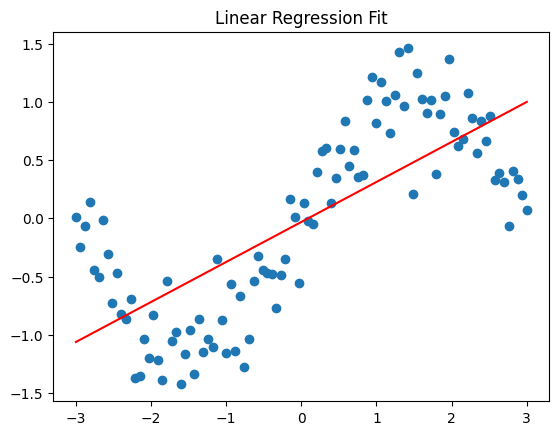

In [48]:
plt.scatter(X_reg, y_reg)
plt.plot(X_reg, y_pred, color='red')
plt.title("Linear Regression Fit")
plt.show()

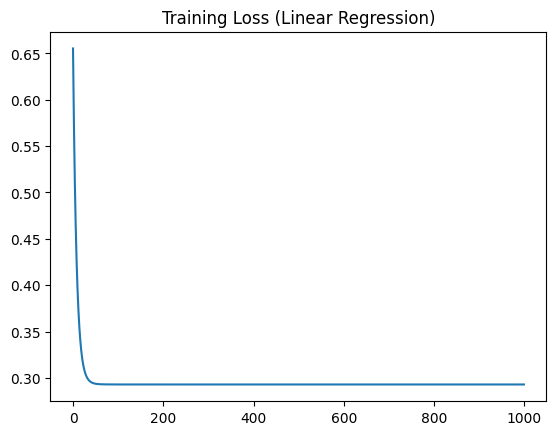

In [49]:
plt.plot(model.losses)
plt.title("Training Loss (Linear Regression)")
plt.show()

In [50]:
model = LogisticRegression()
model.fit(X_clf, y_clf)

y_pred = model.predict(X_clf)

train_error = 1 - accuracy(y_clf, y_pred)
cv_error = k_fold_cv(LogisticRegression, X_clf, y_clf, is_classification=True)
boot_error = bootstrap_error(LogisticRegression, X_clf, y_clf, is_classification=True)

print("Train:", train_error)
print("CV:", cv_error)
print("Bootstrap:", boot_error)

Train: 0.15500000000000003
CV: 0.165
Bootstrap: 0.17325


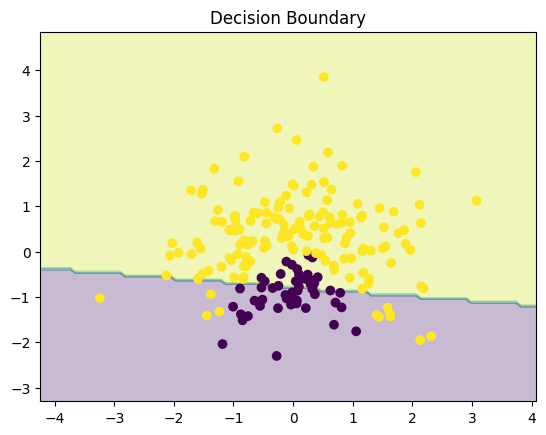

In [51]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, X_clf, y_clf)

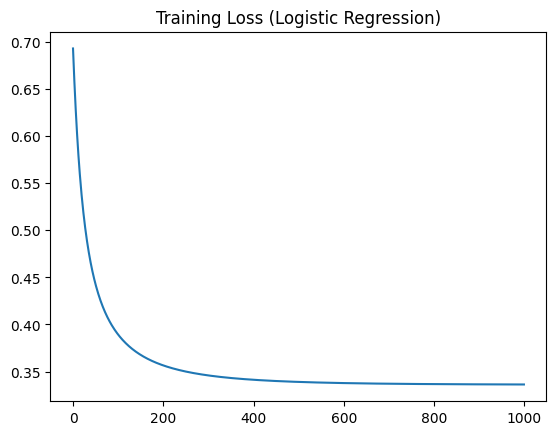

In [52]:
plt.plot(model.losses)
plt.title("Training Loss (Logistic Regression)")
plt.show()

In [53]:
def poly_features(X, degree):
    return np.hstack([X**i for i in range(1, degree+1)])

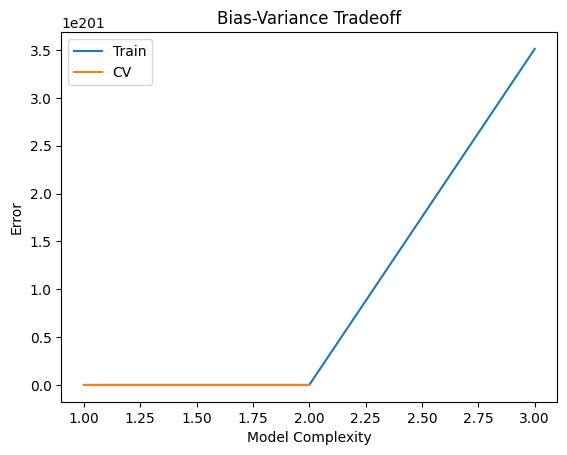

In [54]:
degrees = range(1, 10)
train_errors = []
cv_errors = []

for d in degrees:
    X_poly = poly_features(X_reg, d)

    model = LinearRegression()
    model.fit(X_poly, y_reg)

    y_pred = model.predict(X_poly)

    train_errors.append(mse(y_reg, y_pred))
    cv_errors.append(k_fold_cv(LinearRegression, X_poly, y_reg))

plt.plot(degrees, train_errors, label="Train")
plt.plot(degrees, cv_errors, label="CV")
plt.legend()
plt.title("Bias-Variance Tradeoff")
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.show()